# Centrality and Critical-Edge Vulnerability Analysis

This notebook studies network vulnerability on the shared Los Angeles road graph. Rather than only computing abstract centrality, it measures **operational criticality** directly: remove one edge, rerun the shared simulation, and quantify how much total VMT, average trip time, and congestion worsen.

That gives a presentation-friendly answer to: **which roads are most important because the network performs worse when they fail?**

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "graph_model.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graph_model import SimParams, build_graph, run_scenario, get_baseline_vmt
G = build_graph()

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mplconfig").resolve()))

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Nodes: 71 | Edges: 199


## Baseline Scenario and Method

Baseline parameters use the shared defaults: AM peak, medium background traffic, medium demand, and a 30% robo-taxi share.

For each directed edge `(u, v)`:

1. Copy the graph.
2. Remove that edge to simulate a closure or major failure.
3. Rerun `run_scenario()` on the disrupted graph.
4. Compare the disrupted metrics to baseline.

The main vulnerability measures are:

- `delta_vmt`: increase in total VMT after the edge is removed.
- `delta_avg_trip_time_min`: increase in average trip time.
- `delta_congested_edges`: increase in the number of edges above 0.9 utilization.
- `vulnerability_score`: average percentile rank across the three disruption metrics.

The notebook also compares this empirical disruption score to weighted edge betweenness centrality.

In [2]:
params = SimParams()
baseline = run_scenario(G, params)
baseline_no_rt_vmt = get_baseline_vmt(G, params)
edge_betweenness = nx.edge_betweenness_centrality(G, weight="length_km")

def analyze_edge_closure(graph, params, baseline_result):
    rows = []
    for u, v in graph.edges():
        disrupted = graph.copy()
        disrupted.remove_edge(u, v)
        result = run_scenario(disrupted, params)
        edge_data = graph.edges[u, v]
        rows.append({
            "u": u,
            "v": v,
            "road_name": edge_data.get("road_name", "Unknown"),
            "direction": edge_data.get("direction", ""),
            "length_km": edge_data.get("length_km", 0.0),
            "capacity_vph": edge_data.get("capacity_vph", 0.0),
            "baseline_flow_vph": baseline_result["edge_flow"][(u, v)],
            "baseline_utilization": baseline_result["utilization"][(u, v)],
            "betweenness": edge_betweenness[(u, v)],
            "total_vmt": result["total_vmt"],
            "avg_trip_time_min": result["avg_trip_time_min"],
            "congested_edge_count": result["congested_edge_count"],
            "unmet_demand": result["unmet_demand"],
            "delta_vmt": result["total_vmt"] - baseline_result["total_vmt"],
            "delta_avg_trip_time_min": result["avg_trip_time_min"] - baseline_result["avg_trip_time_min"],
            "delta_congested_edges": result["congested_edge_count"] - baseline_result["congested_edge_count"],
        })
    df = pd.DataFrame(rows)
    df["pct_vmt_change"] = 100.0 * df["delta_vmt"] / baseline_result["total_vmt"]
    df["pct_trip_time_change"] = 100.0 * df["delta_avg_trip_time_min"] / baseline_result["avg_trip_time_min"]
    df["vulnerability_score"] = (
        df["delta_vmt"].rank(pct=True) +
        df["delta_avg_trip_time_min"].rank(pct=True) +
        df["delta_congested_edges"].rank(pct=True)
    ) / 3.0
    return df.sort_values(["vulnerability_score", "delta_vmt"], ascending=False).reset_index(drop=True)

closure_df = analyze_edge_closure(G, params, baseline)

baseline_summary = pd.DataFrame([
    {
        "baseline_total_vmt": baseline["total_vmt"],
        "baseline_avg_trip_time_min": baseline["avg_trip_time_min"],
        "baseline_congested_edges": baseline["congested_edge_count"],
        "baseline_deadhead_vmt": baseline["deadhead_vmt"],
        "baseline_no_robotaxi_vmt": baseline_no_rt_vmt,
        "robotaxi_vmt_delta_vs_no_rt": baseline["total_vmt"] - baseline_no_rt_vmt,
    }
])

display(baseline_summary.round(3))
display(closure_df.head(12).round(3))

,baseline_total_vmt,baseline_avg_trip_time_min,baseline_congested_edges,baseline_deadhead_vmt,baseline_no_robotaxi_vmt,robotaxi_vmt_delta_vs_no_rt
0,"2,297,146.130",12.853,4,"6,841.943","2,269,741.317","27,404.813"


,u,v,road_name,direction,length_km,capacity_vph,baseline_flow_vph,baseline_utilization,betweenness,total_vmt,avg_trip_time_min,congested_edge_count,unmet_demand,delta_vmt,delta_avg_trip_time_min,delta_congested_edges,pct_vmt_change,pct_trip_time_change,vulnerability_score
0,23,30,Glendale Boulevard,inbound,1.014,"5,400.000","3,497.715",0.648,0.036,"2,296,191.132",12.939,5,0.000,-954.998,0.086,1,-0.042,0.667,0.928
1,40,38,West Olympic Boulevard,outbound,1.255,"10,800.000","8,802.086",0.815,0.035,"2,292,708.780",13.611,7,0.000,"-4,437.350",0.758,3,-0.193,5.899,0.915
2,69,35,West Slauson Avenue,outbound,1.051,"7,200.000","4,854.628",0.674,0.032,"2,293,626.458",12.958,5,0.000,"-3,519.672",0.105,1,-0.153,0.816,0.905
3,55,54,South Alameda Street,inbound,1.105,"7,200.000","4,203.328",0.584,0.060,"2,293,000.500",12.883,5,0.000,"-4,145.630",0.030,1,-0.180,0.234,0.849
4,76,77,East Slauson Avenue,inbound,1.217,"7,200.000","6,492.685",0.902,0.118,"2,302,762.816",14.157,4,0.000,"5,616.686",1.304,0,0.245,10.148,0.840
5,57,76,East Slauson Avenue,inbound,0.550,"7,200.000","6,306.177",0.876,0.115,"2,304,311.342",13.986,4,0.000,"7,165.212",1.133,0,0.312,8.816,0.838
6,39,17,Wilshire Boulevard,outbound,1.497,"12,600.000","8,811.350",0.699,0.033,"2,288,948.104",13.094,6,0.000,"-8,198.026",0.241,2,-0.357,1.877,0.815
7,6,4,Mission Road,inbound,0.465,"7,200.000","4,669.779",0.649,0.031,"2,296,626.167",13.006,4,0.000,-519.963,0.153,0,-0.023,1.194,0.810
8,59,23,CA-2,inbound,0.732,"3,600.000","2,353.885",0.654,0.024,"2,294,759.909",12.944,4,0.000,"-2,386.221",0.091,0,-0.104,0.705,0.780
9,77,69,East Slauson Avenue,outbound,2.271,"7,200.000","4,798.990",0.667,0.042,"2,288,753.319",12.959,5,0.000,"-8,392.811",0.107,1,-0.365,0.829,0.779


## Visual Ranking and Centrality Comparison

The first panel ranks the most vulnerable directed edges by disruption score. The second checks whether high-flow edges are also the most damaging to lose. The third compares empirical vulnerability to edge betweenness, and the fourth aggregates the worst disruptions to the road-name level for a cleaner policy narrative.

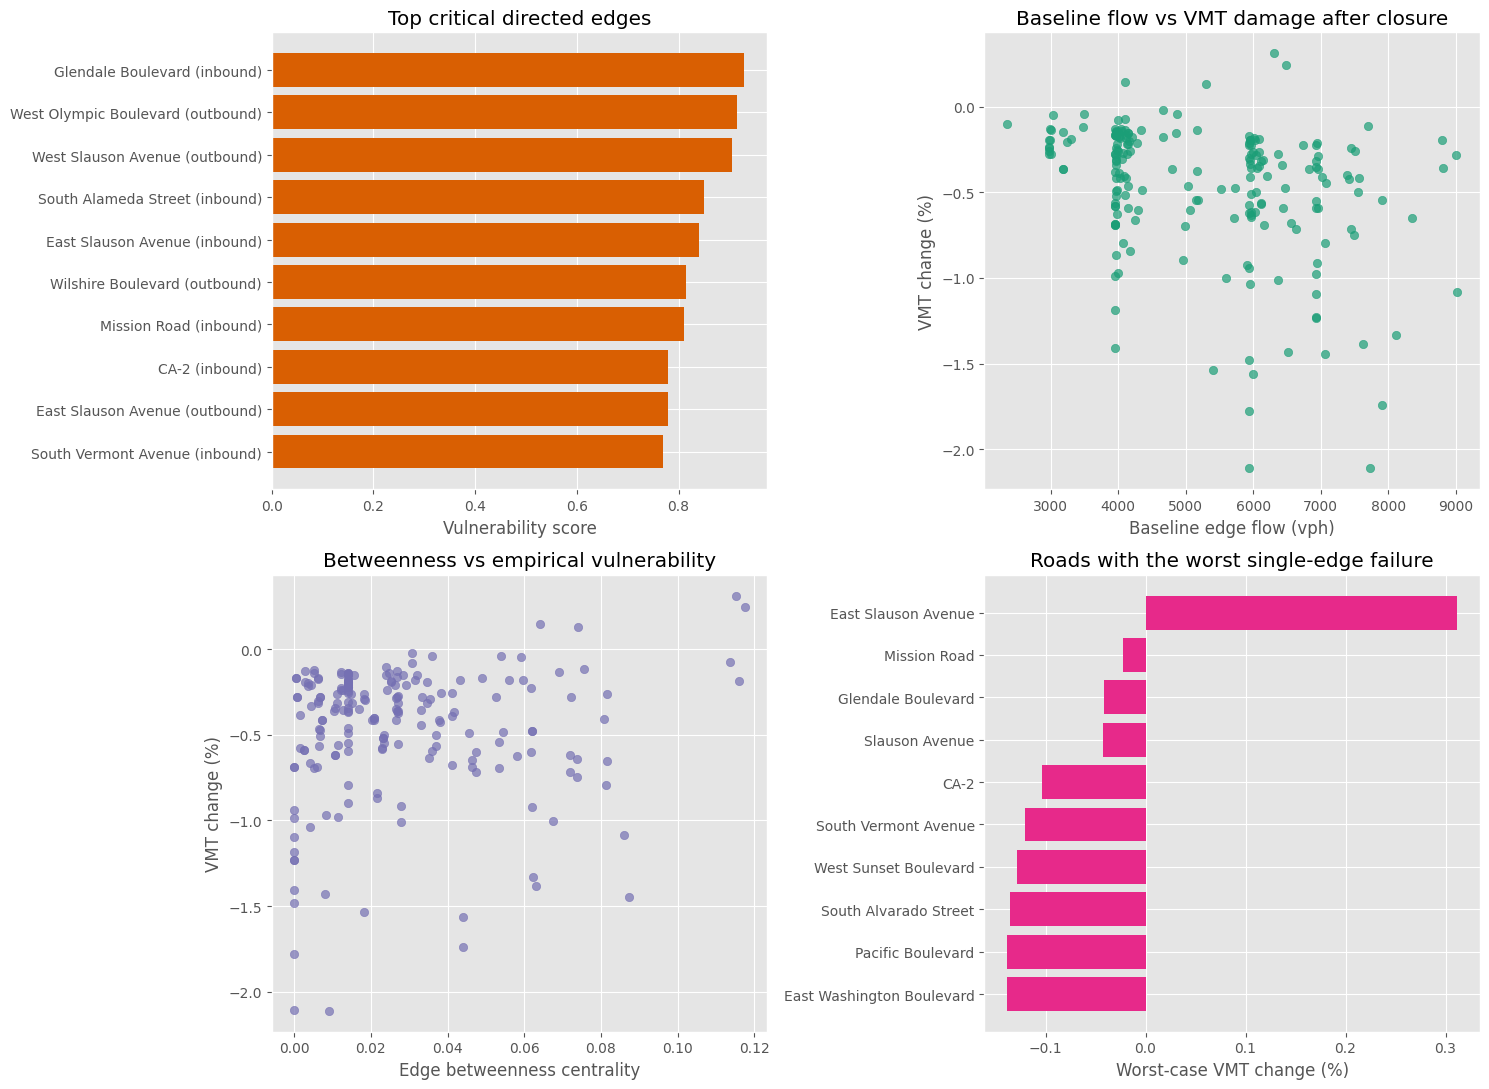

,road_name,mean_vulnerability_score,max_pct_vmt_change,mean_baseline_flow_vph,edge_count
5,East Slauson Avenue,0.671,0.312,"4,908.418",14
14,Mission Road,0.542,-0.023,"4,930.733",6
8,Glendale Boulevard,0.631,-0.042,"3,703.814",4
25,Slauson Avenue,0.485,-0.043,"3,758.942",4
2,CA-2,0.661,-0.104,"2,839.447",3
32,South Vermont Avenue,0.524,-0.120,"4,798.054",13
41,West Sunset Boulevard,0.485,-0.129,"5,876.284",10
27,South Alvarado Street,0.609,-0.136,"5,134.512",6
21,Pacific Boulevard,0.495,-0.138,"6,243.366",4
7,East Washington Boulevard,0.467,-0.139,"4,251.953",8


Correlation: betweenness vs pct VMT change = 0.101
Correlation: baseline flow vs pct VMT change = -0.337


In [3]:
top_edges = closure_df.head(12).copy()
top_edges["label"] = top_edges.apply(lambda r: f"{r['road_name']} ({r['direction']})", axis=1)

road_agg = (
    closure_df.groupby("road_name", as_index=False)
    .agg(
        mean_vulnerability_score=("vulnerability_score", "mean"),
        max_pct_vmt_change=("pct_vmt_change", "max"),
        mean_baseline_flow_vph=("baseline_flow_vph", "mean"),
        edge_count=("road_name", "size"),
    )
    .sort_values(["max_pct_vmt_change", "mean_vulnerability_score"], ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

axes[0, 0].barh(top_edges["label"][::-1], top_edges["vulnerability_score"][::-1], color="#d95f02")
axes[0, 0].set_title("Top critical directed edges")
axes[0, 0].set_xlabel("Vulnerability score")

axes[0, 1].scatter(closure_df["baseline_flow_vph"], closure_df["pct_vmt_change"], alpha=0.7, color="#1b9e77")
axes[0, 1].set_title("Baseline flow vs VMT damage after closure")
axes[0, 1].set_xlabel("Baseline edge flow (vph)")
axes[0, 1].set_ylabel("VMT change (%)")

axes[1, 0].scatter(closure_df["betweenness"], closure_df["pct_vmt_change"], alpha=0.7, color="#7570b3")
axes[1, 0].set_title("Betweenness vs empirical vulnerability")
axes[1, 0].set_xlabel("Edge betweenness centrality")
axes[1, 0].set_ylabel("VMT change (%)")

top_roads = road_agg.head(10).sort_values("max_pct_vmt_change")
axes[1, 1].barh(top_roads["road_name"], top_roads["max_pct_vmt_change"], color="#e7298a")
axes[1, 1].set_title("Roads with the worst single-edge failure")
axes[1, 1].set_xlabel("Worst-case VMT change (%)")

plt.tight_layout()
plt.show()

display(road_agg.head(10).round(3))
print("Correlation: betweenness vs pct VMT change =", round(closure_df["betweenness"].corr(closure_df["pct_vmt_change"]), 3))
print("Correlation: baseline flow vs pct VMT change =", round(closure_df["baseline_flow_vph"].corr(closure_df["pct_vmt_change"]), 3))

## Time-of-Day Sensitivity for the Most Critical Edges

A road can be structurally important but only fragile during a particular demand pattern. This final section re-evaluates the top baseline-critical edges under AM peak, midday, and PM peak demand to see whether vulnerability is stable or highly time dependent.

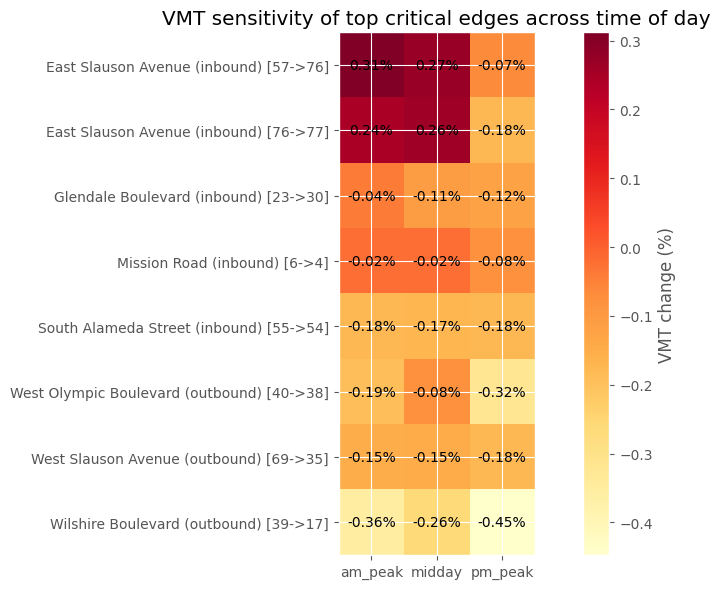

,time_of_day,edge,pct_vmt_change,delta_avg_trip_time_min
5,am_peak,East Slauson Avenue (inbound) [57->76],0.312,1.133
4,am_peak,East Slauson Avenue (inbound) [76->77],0.245,1.304
7,am_peak,Mission Road (inbound) [6->4],-0.023,0.153
0,am_peak,Glendale Boulevard (inbound) [23->30],-0.042,0.086
2,am_peak,West Slauson Avenue (outbound) [69->35],-0.153,0.105
3,am_peak,South Alameda Street (inbound) [55->54],-0.180,0.030
1,am_peak,West Olympic Boulevard (outbound) [40->38],-0.193,0.758
6,am_peak,Wilshire Boulevard (outbound) [39->17],-0.357,0.241
13,midday,East Slauson Avenue (inbound) [57->76],0.272,0.434
12,midday,East Slauson Avenue (inbound) [76->77],0.262,0.577


In [4]:
top_candidates = closure_df.head(8)[["u", "v", "road_name", "direction"]].copy()
top_candidates["edge_label"] = top_candidates.apply(
    lambda r: f"{r['road_name']} ({r['direction']}) [{r['u']}->{r['v']}]", axis=1
)
tod_labels = ["am_peak", "midday", "pm_peak"]
sensitivity_rows = []

for tod in tod_labels:
    tod_params = SimParams(time_of_day=tod)
    tod_baseline = run_scenario(G, tod_params)
    for row in top_candidates.itertuples(index=False):
        disrupted = G.copy()
        disrupted.remove_edge(row.u, row.v)
        result = run_scenario(disrupted, tod_params)
        sensitivity_rows.append({
            "time_of_day": tod,
            "edge": row.edge_label,
            "pct_vmt_change": 100.0 * (result["total_vmt"] - tod_baseline["total_vmt"]) / tod_baseline["total_vmt"],
            "delta_avg_trip_time_min": result["avg_trip_time_min"] - tod_baseline["avg_trip_time_min"],
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
heatmap = sensitivity_df.pivot(index="edge", columns="time_of_day", values="pct_vmt_change")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap.values, cmap="YlOrRd")
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_title("VMT sensitivity of top critical edges across time of day")

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        ax.text(j, i, f"{heatmap.values[i, j]:.2f}%", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="VMT change (%)")
plt.tight_layout()
plt.show()

display(sensitivity_df.sort_values(["time_of_day", "pct_vmt_change"], ascending=[True, False]).round(3))

## Takeaways

- The most important edges are not just the busiest ones; they are the ones whose loss forces long detours or shifts congestion onto already stressed parallel corridors.
- Comparing betweenness to simulated disruption helps distinguish **structural centrality** from **operational fragility**.
- Road-level aggregation is useful for presentation because it converts edge-level failures into a shortlist of corridors that are natural policy or resilience targets.